In [ ]:
# --- ÉTAPE 1 : Importation des bibliothèques ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:


# --- ÉTAPE 2 : Chargement des données ---
# Assurez-vous que le fichier est dans le même dossier que votre notebook
df = pd.read_csv('taux_tension.csv')

In [ ]:

# --- ÉTAPE 3 : Calcul des KPIs du Volume de Marché ---
total_logements = df['nombre_de_lots_a_usage_d_habitation'].sum()
total_parkings = df['nombre_de_lots_de_stationnement'].sum()
deficit_places = total_logements - total_parkings

print(f"--- ANALYSE DU VOLUME DE MARCHÉ ---")
print(f"Taille totale de la cible (Logements) : {total_logements}")
print(f"Offre existante (Parkings) : {total_parkings}")
print(f"Déficit brut (Opportunité de marché) : {deficit_places} places manquantes")

In [ ]:
# --- ÉTAPE 4 : Segmentation de la cible par Ville ---
# On regroupe par commune pour voir où se situe le volume
market_by_city = df.groupby('nom_officiel_departement').agg({
    'nombre_de_lots_a_usage_d_habitation': 'sum',
    'nombre_de_lots_de_stationnement': 'sum'
}).reset_index()

market_by_city['deficit'] = market_by_city['nombre_de_lots_a_usage_d_habitation'] - market_by_city['nombre_de_lots_de_stationnement']


In [ ]:
# --- ÉTAPE 5 : Visualisation ---

# Configuration du style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Graphique : Volume de logements vs Places disponibles
market_by_city.plot(x='nom_officiel_departement', 
                    y=['nombre_de_lots_a_usage_d_habitation', 'nombre_de_lots_de_stationnement'], 
                    kind='bar', 
                    color=['#3498db', '#e74c3c'],
                    figsize=(12,6))

plt.title('Volume de Marché : Logements vs Parkings par Département', fontsize=15)
plt.ylabel('Nombre de Lots')
plt.xlabel('Département')
plt.legend(['Logements (La Cible)', 'Parkings (L\'Offre)'])
plt.xticks(rotation=45)
plt.show()

--- ANALYSE DU VOLUME DE MARCHÉ ---
Taille totale de la cible (Logements) : 3678151.0
Offre existante (Parkings) : 2092620.0
Déficit brut (Opportunité de marché) : 1585531.0 places manquantes


<Figure size 1200x600 with 0 Axes>

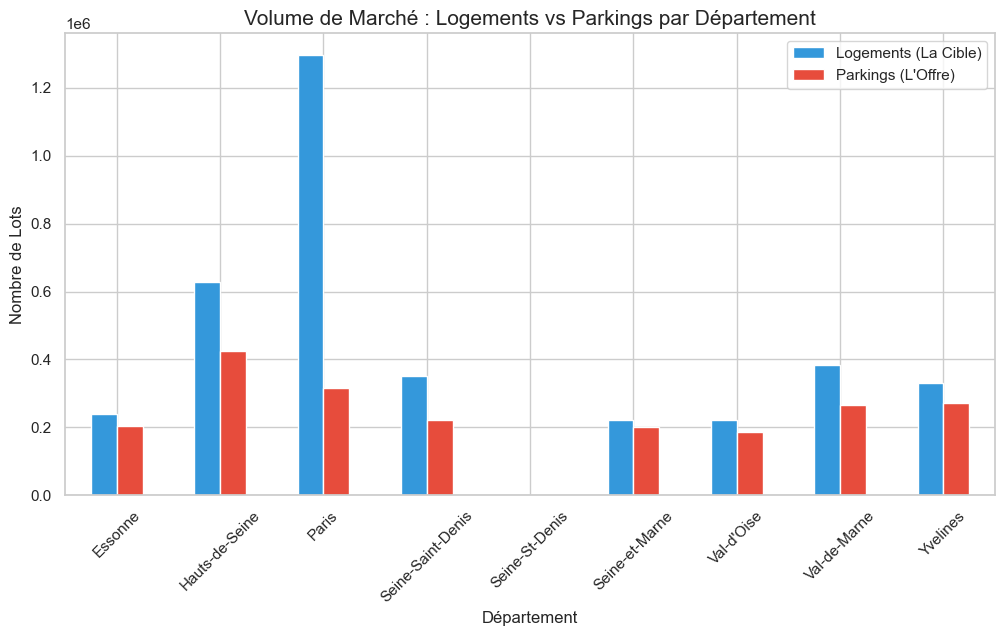

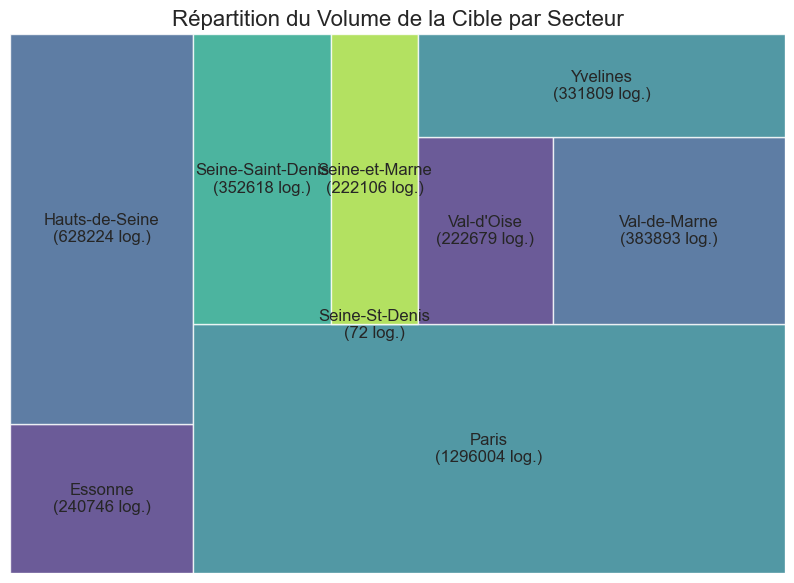

In [5]:
# --- ÉTAPE 6 : Graphique en "Treemap" pour la part de marché ---
import squarify

plt.figure(figsize=(10, 7))
labels = [f"{city}\n({int(val)} log.)" for city, val in zip(market_by_city['nom_officiel_departement'], market_by_city['nombre_de_lots_a_usage_d_habitation'])]
squarify.plot(sizes=market_by_city['nombre_de_lots_a_usage_d_habitation'], label=labels, alpha=.8, color=sns.color_palette("viridis"))
plt.title("Répartition du Volume de la Cible par Secteur", fontsize=16)
plt.axis('off')
plt.show()

In [6]:
df.to_csv("volume_de_marché.csv", index=False)